In [1]:
import matplotlib.pyplot as plt
import matplotlib as mpl
import numpy as np
import math
from cycler import cycler

# Define high-contrast color palette
# 1. Deep Blue, 2. Brick Red, 3. Forest Green, 4. Muted Purple, 5. Safety Orange, 
# 6. Chestnut Brown, 7. Raspberry Pink, 8. Slate Gray, 9. Olive Gold, 10. Teal/Cyan

general_colors = ['#1f77b4','#d62728','#2ca02c','#9467bd','#ff7f0e','#8c564b','#e377c2','#7f7f7f','#bcbd22','#17becf' ]
light_colors = ['#0047AB',  '#FF0000',  '#00CC00',  '#9932CC',  '#FF8C00',  '#FF00FF',  '#FFD700',  '#00CED1',  '#FF4500',  '#7FFF00']

# General graph settings
plt.rcParams.update({
    # Font settings
    'font.family': 'sans-serif',          # Universal font family
    'font.sans-serif': ['Helvetica', 'Arial', 'DejaVu Sans'], # Fallback fonts
    # 'font.family': 'serif',          # Cambiato da sans-serif a serif
    # 'font.serif': ['Computer Modern', 'Times New Roman', 'DejaVu Serif'], # Lista di font serif
    'mathtext.fontset': 'cm',        # Imposta i simboli matematici nello stile di LaTeX (Computer Modern
    # 'mathtext.fontset': 'stix',           # Makes LaTeX math symbols match the text font style
    
    # Color cycle settings
    'axes.prop_cycle': cycler(color=light_colors), # Sets the default color sequence for multiple lines
    
    # Size and resolution
    'font.size': 14,                      # General font size
    'axes.labelsize': 14,                 # Size of axis labels (x, y)
    'axes.titlesize': 16,                 # Size of the plot title
    'legend.fontsize': 12,                # Legend font size
    
    # Line and marker aesthetics
    'lines.linewidth': 2,                 # Line width
    'lines.markersize': 5,                # Marker size
    'figure.figsize': (10, 6),            # Default figure size
    
    # Grid settings
    'axes.grid': True,                    # Enable grid by default
    'grid.alpha': 0.4,                    # Make grid slightly transparent
    'grid.linestyle': '--',               # Dashed grid style
    'errorbar.capsize': False             # Add caps to error bars
})

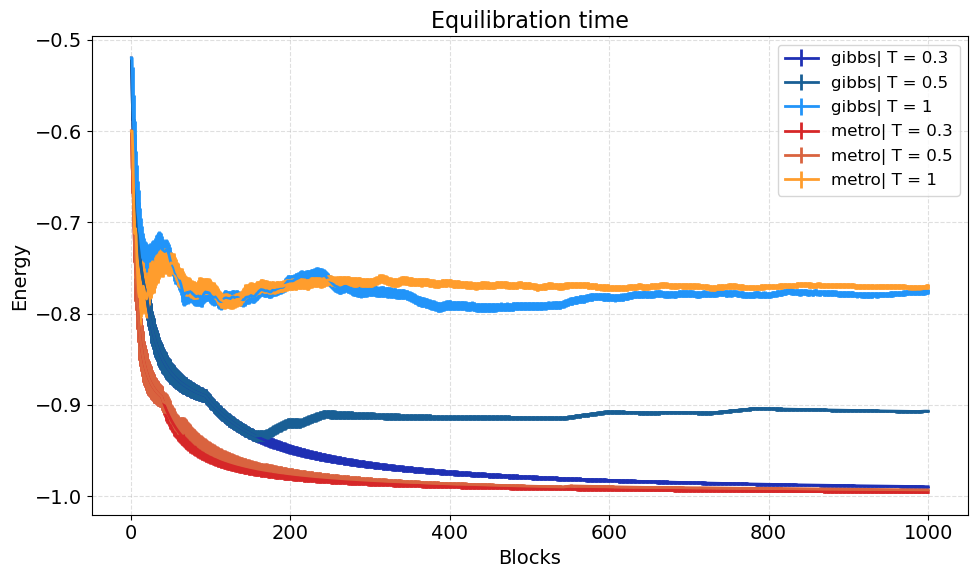

In [2]:

# Parameters
t_equilibs = ['0.3', '0.5', '1']
methods = ['gibbs', 'metro']
colors = ["#1f30b4", "#195f95", "#2194f9", '#d62728', "#d9633f", "#ff9d2d"]

plt.figure()
i=0
for method in methods:
    for T in t_equilibs:   
        data = np.loadtxt("NSL_SIMULATOR/equilib_" + method + "/OUTPUT_T=" + T + "/total_energy.dat")
        blocks = data[:, 0]
        energy_single = data[:, 1]
        energy_progressive = data[:, 2]
        error = data[:, 3]

        #plt.plot(blocks, energy_single, label='Single data ' + method)
        plt.errorbar(blocks, energy_progressive, error, label= method + '| T = ' + T, color = colors[i])
        i = i+1

# Formattazione
plt.title('Equilibration time')
plt.xlabel('Blocks')
plt.ylabel('Energy')
plt.legend(loc='best', frameon=True)
plt.tight_layout()
plt.show()




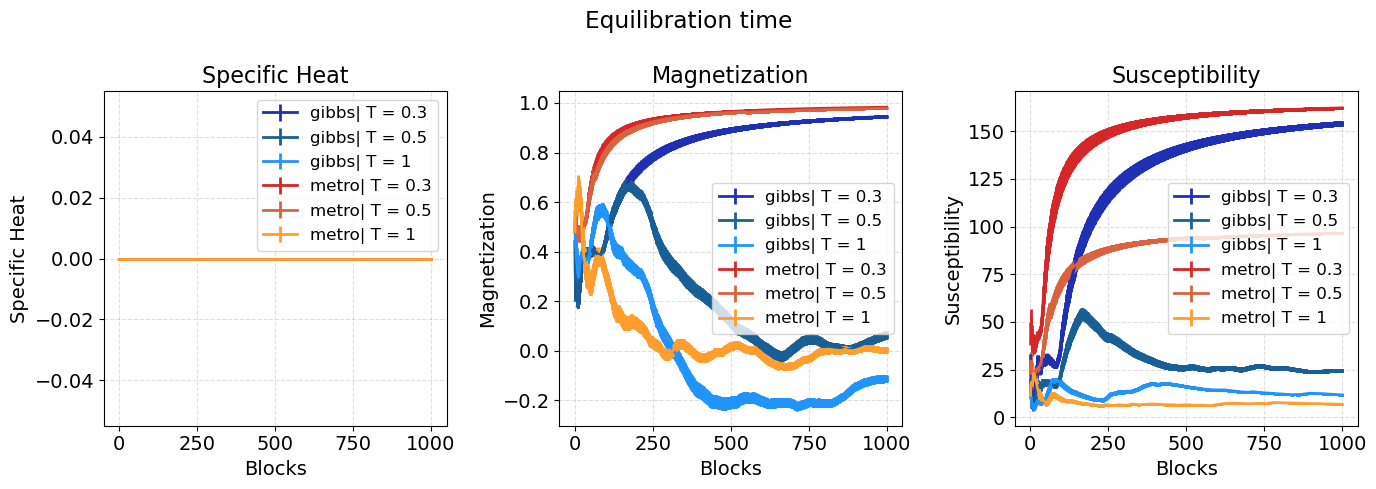

In [4]:
t_equilibs = ['0.3', '0.5', '1']
methods = ['gibbs', 'metro']
colors = ["#1f30b4", "#195f95", "#2194f9", '#d62728', "#d9633f", "#ff9d2d"]

 # Creazione del grafico
fig, ax = plt.subplots(ncols=3, nrows=1, figsize = (14, 5))
plt.suptitle('Equilibration time')

i=0
for method in methods:
    for T in t_equilibs:   
        data = np.loadtxt("NSL_SIMULATOR/equilib_" + method + "/OUTPUT_T=" + T + "/specific_heat.dat")

        ax[0].errorbar(data[:, 0], data[:, 2], data[:, 3], label= method + '| T = ' + T, color = colors[i])
        i = i+1


ax[0].set_title('Specific Heat')
ax[0].set_xlabel('Blocks')
ax[0].set_ylabel('Specific Heat')
ax[0].legend(loc='best', frameon=True)

i=0
for method in methods:
    for T in t_equilibs:   
        data = np.loadtxt("NSL_SIMULATOR/equilib_" + method + "/OUTPUT_T=" + T + "/magnetization.dat")

        ax[1].errorbar(data[:, 0], data[:, 2], data[:, 3], label= method + '| T = ' + T, color = colors[i])
        i = i+1

ax[1].set_title('Magnetization')
ax[1].set_xlabel('Blocks')
ax[1].set_ylabel('Magnetization')
ax[1].legend(loc='best', frameon=True)

i=0
for method in methods:
    for T in t_equilibs:   
        data = np.loadtxt("NSL_SIMULATOR/equilib_" + method + "/OUTPUT_T=" + T + "/susceptibility.dat")

        ax[2].errorbar(data[:, 0], data[:, 2], data[:, 3], label= method + '| T = ' + T, color = colors[i])
        i = i+1

ax[2].set_title('Susceptibility')
ax[2].set_xlabel('Blocks')
ax[2].set_ylabel('Susceptibility')
ax[2].legend(loc='best', frameon=True)



plt.tight_layout()


In [ ]:

def data_blocking(data, block_size):
    n_data = len(data)
    n_blocks = n_data//block_size #Divisione intera

    # Prevenzione: scarta gli ultimi dati se n_data non è un multiplo esatto di block_size
    # data = data[:n_blocks * block_size]

    ave = np.zeros(n_blocks)
    av2 = np.zeros(n_blocks)
    err_prog = np.zeros(n_blocks)

    sum_prog = np.zeros(n_blocks)
    su2_prog = np.zeros(n_blocks)
    
    current_tot = 0
    current_to2 = 0
    counter = 0

    for i in range(n_blocks) :
        provv = 0
        for j in range(block_size) : 
            provv = provv + data[counter]
            counter = counter + 1
        ave[i] = provv / block_size
        av2[i] = ave[i] * ave[i]

        current_tot = current_tot + ave[i]
        current_to2 = current_to2 + av2[i]

        sum_prog[i] = current_tot / (i+1)
        su2_prog[i] = current_to2 / (i+1)

        err_prog[i] = calcola_errore(sum_prog[i], su2_prog[i], i)

    x = np.arange(1, n_data + 1, block_size)

    return [x, ave, sum_prog, err_prog]